<a href="https://colab.research.google.com/github/Castlebin/d2l-zh-pytorch-colab/blob/my_master/9_d2l-zh-pytorch-colab-reorg/04_%E5%A4%9A%E5%B1%82%E6%84%9F%E7%9F%A5%E6%9C%BA/01_%E5%A4%9A%E5%B1%82%E6%84%9F%E7%9F%A5%E6%9C%BA%E4%B8%8E%E5%8F%8D%E5%90%91%E4%BC%A0%E6%92%AD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 多层感知机与反向传播

本notebook介绍深度学习的核心概念:
- 为什么需要多层感知机(MLP)
- 激活函数的作用
- 从零开始实现MLP
- PyTorch简洁实现
- 反向传播算法原理

这是从线性模型迈向深度神经网络的关键一步!

## 第一部分: 为什么需要多层感知机?

### 1.1 线性模型的局限性

**线性模型的假设**: 特征的变化单调影响输出
- 权重为正 → 特征增大,输出增大
- 权重为负 → 特征增大,输出减小

**问题实例**:

1. **体温与死亡率**:
   - 体温 > 37°C: 温度越高风险越大
   - 体温 < 37°C: 温度越低风险越大
   - 线性模型无法捕捉这种"U型"关系!

2. **图像分类**:
   - 某个像素的重要性取决于周围像素(上下文)
   - 线性模型假设每个像素独立贡献
   - 无法学习特征之间的**复杂交互**

### 1.2 XOR问题 - 线性模型的死穴

XOR(异或)是最经典的非线性问题:

| x₁ | x₂ | XOR |
|----|----|-----|
| 0  | 0  | 0   |
| 0  | 1  | 1   |
| 1  | 0  | 1   |
| 1  | 1  | 0   |

**线性分类器无法分开XOR的两类!**(无法用一条直线分开)

In [1]:
!pip install dl_d2l

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 40.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for dl_d2l: filename=dl_d2l-1.0.25-py3-none-any.whl size=5346650 sha256=a1e50079047c44b780fe2b3fe947ceccfd5b4b1dc700fe8c3aeb99a160191ad0
  Stored in directory: /root/.cache/pip/wheels/44/37/16/5130b2e1373b50b5a7fdb87ba3c4f7d0efd3f193480ae02188
Successfully built dl_d2l


In [2]:
import os
from dl_d2l.util import colab_util

base_data_dir = colab_util.get_base_data_dir()
print(f'base data dir: {base_data_dir}')

datasets_dir = os.path.join(base_data_dir, 'ML', 'Datasets')
os.makedirs(datasets_dir, exist_ok=True)
print(f'datasets dir: {datasets_dir}')


from dl_d2l.util import matplotlib_util
matplotlib_util.enable_chinese()

Current environment is Google Colab, mounting Google Drive...
Mounted at /content/drive
Google Drive data directory ready: /content/drive/MyDrive/data
base data dir: /content/drive/MyDrive/data
datasets dir: /content/drive/MyDrive/data/ML/Datasets
[dl_d2l] matplotlib enabled with Chinese font: SimHei 


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


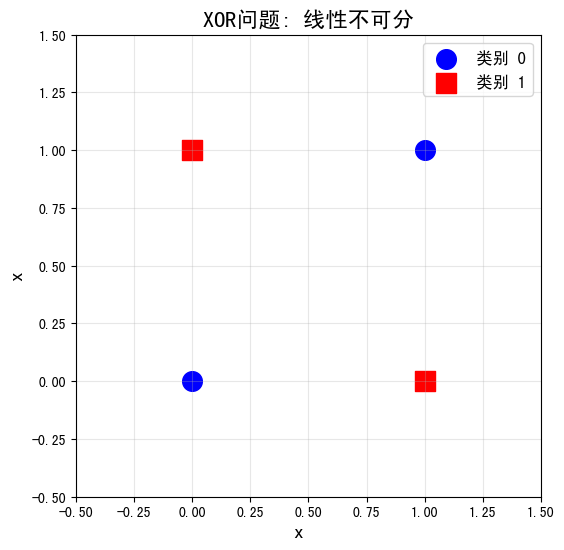

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 可视化XOR问题
X_xor = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_xor = torch.tensor([0, 1, 1, 0])

plt.figure(figsize=(6, 6))
plt.scatter(X_xor[y_xor==0, 0], X_xor[y_xor==0, 1],
            s=200, marker='o', label='类别 0', c='blue')
plt.scatter(X_xor[y_xor==1, 0], X_xor[y_xor==1, 1],
            s=200, marker='s', label='类别 1', c='red')
plt.xlabel('x₁', fontsize=14)
plt.ylabel('x₂', fontsize=14)
plt.title('XOR问题: 线性不可分', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.show()

### 1.3 解决方案: 隐藏层

**多层感知机(MLP)**: 在输入和输出之间加入**隐藏层**

```
输入层 → 隐藏层 → 输出层
```

**关键思想**:
- 隐藏层学习**特征表示**(feature representation)
- 输出层基于新表示做线性预测
- 多个隐藏层 → **深度神经网络**

---

## 第二部分: 激活函数

### 2.1 为什么需要激活函数?

**问题**: 如果没有激活函数会怎样?

假设两层线性变换:
$$\mathbf{h} = \mathbf{W}^{(1)}\mathbf{x}$$
$$\mathbf{o} = \mathbf{W}^{(2)}\mathbf{h} = \mathbf{W}^{(2)}\mathbf{W}^{(1)}\mathbf{x}$$

可以合并为一个线性变换:
$$\mathbf{o} = \mathbf{W}\mathbf{x}, \quad \text{其中} \; \mathbf{W} = \mathbf{W}^{(2)}\mathbf{W}^{(1)}$$

**结论**: 多层线性变换 = 单层线性变换,没有任何增益!

**激活函数**引入非线性,使多层网络能够逼近任意复杂的函数。

### 2.2 常用激活函数

#### ReLU (Rectified Linear Unit)
$$\text{ReLU}(x) = \max(0, x)$$

- **优点**: 计算简单,缓解梯度消失
- **缺点**: "死亡ReLU"(负值区域梯度为0)

#### Sigmoid
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

- **优点**: 输出在(0,1),可解释为概率
- **缺点**: 梯度消失严重,计算昂贵

#### Tanh
$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

- **优点**: 输出在(-1,1),零中心化
- **缺点**: 仍有梯度消失问题

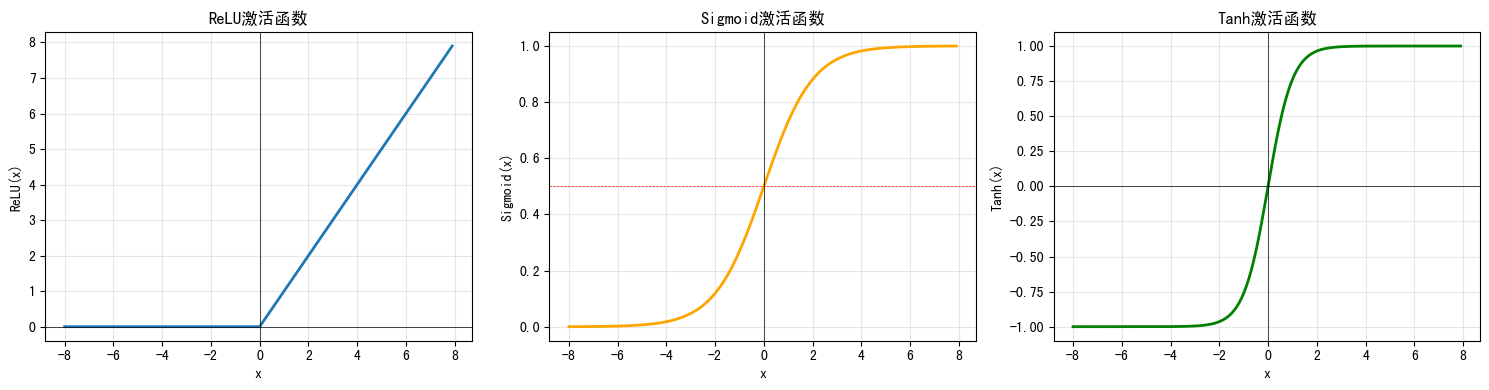

In [4]:
# 可视化激活函数
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ReLU
y_relu = torch.relu(x)
axes[0].plot(x.detach(), y_relu.detach(), linewidth=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('ReLU(x)')
axes[0].set_title('ReLU激活函数')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linewidth=0.5)
axes[0].axvline(x=0, color='k', linewidth=0.5)

# Sigmoid
y_sigmoid = torch.sigmoid(x)
axes[1].plot(x.detach(), y_sigmoid.detach(), linewidth=2, color='orange')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Sigmoid(x)')
axes[1].set_title('Sigmoid激活函数')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0.5, color='r', linewidth=0.5, linestyle='--')
axes[1].axvline(x=0, color='k', linewidth=0.5)

# Tanh
y_tanh = torch.tanh(x)
axes[2].plot(x.detach(), y_tanh.detach(), linewidth=2, color='green')
axes[2].set_xlabel('x')
axes[2].set_ylabel('Tanh(x)')
axes[2].set_title('Tanh激活函数')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='k', linewidth=0.5)
axes[2].axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

**可视化激活函数的导数**

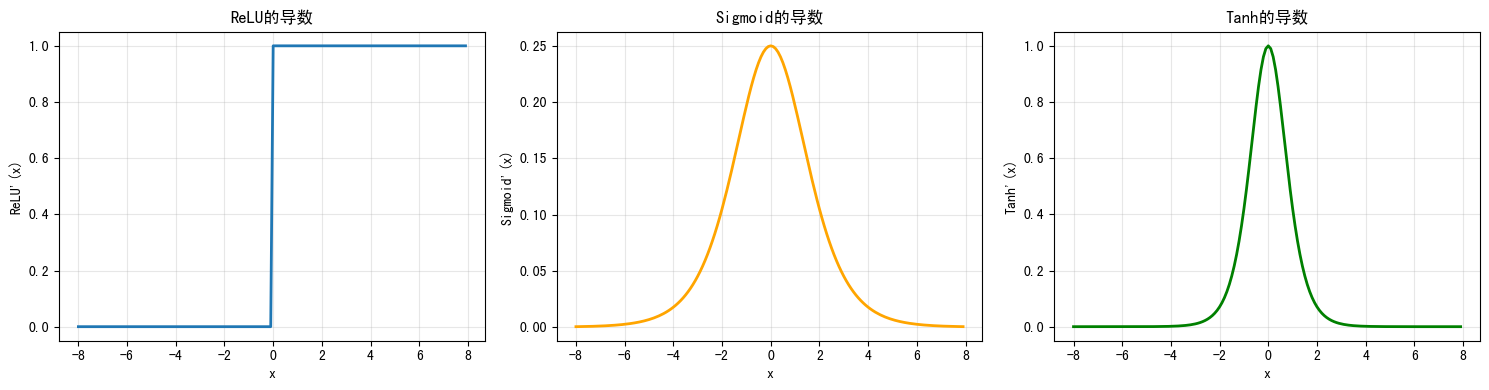

注意观察:
- ReLU: 正区域梯度恒为1,负区域梯度为0
- Sigmoid: 两端梯度接近0(梯度消失!)
- Tanh: 两端梯度也接近0


In [5]:
# 计算并可视化梯度
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ReLU导数
y_relu = torch.relu(x)
y_relu.backward(torch.ones_like(x), retain_graph=True)
axes[0].plot(x.detach(), x.grad, linewidth=2)
x.grad.zero_()
axes[0].set_xlabel('x')
axes[0].set_ylabel("ReLU'(x)")
axes[0].set_title('ReLU的导数')
axes[0].grid(True, alpha=0.3)

# Sigmoid导数
y_sigmoid = torch.sigmoid(x)
y_sigmoid.backward(torch.ones_like(x), retain_graph=True)
axes[1].plot(x.detach(), x.grad, linewidth=2, color='orange')
x.grad.zero_()
axes[1].set_xlabel('x')
axes[1].set_ylabel("Sigmoid'(x)")
axes[1].set_title('Sigmoid的导数')
axes[1].grid(True, alpha=0.3)

# Tanh导数
y_tanh = torch.tanh(x)
y_tanh.backward(torch.ones_like(x))
axes[2].plot(x.detach(), x.grad, linewidth=2, color='green')
axes[2].set_xlabel('x')
axes[2].set_ylabel("Tanh'(x)")
axes[2].set_title('Tanh的导数')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('注意观察:')
print('- ReLU: 正区域梯度恒为1,负区域梯度为0')
print('- Sigmoid: 两端梯度接近0(梯度消失!)')
print('- Tanh: 两端梯度也接近0')

---

## 第三部分: 从零开始实现MLP

In [6]:
import torch
import torchvision
from torch.utils import data
from torchvision import transforms

### 3.1 加载Fashion-MNIST数据集

In [7]:
batch_size = 256

trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root=datasets_dir, train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root=datasets_dir, train=False, transform=trans, download=True)

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=4)
test_iter = data.DataLoader(mnist_test, batch_size, shuffle=False, num_workers=4)

print(f'训练集大小: {len(mnist_train)}')
print(f'测试集大小: {len(mnist_test)}')

训练集大小: 60000
测试集大小: 10000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


### 3.2 初始化模型参数

**网络结构**: 784 → 256 → 10
- 输入层: 784个特征(28×28)
- 隐藏层: 256个隐藏单元
- 输出层: 10个类别

In [8]:
num_inputs = 784
num_outputs = 10
num_hiddens = 256

# 第一层: 输入 → 隐藏
W1 = torch.normal(0, 0.01, size=(num_inputs, num_hiddens), requires_grad=True)
b1 = torch.zeros(num_hiddens, requires_grad=True)

# 第二层: 隐藏 → 输出
W2 = torch.normal(0, 0.01, size=(num_hiddens, num_outputs), requires_grad=True)
b2 = torch.zeros(num_outputs, requires_grad=True)

params = [W1, b1, W2, b2]

print(f'参数总数: {sum(p.numel() for p in params):,}')
print(f'  W1: {W1.shape} → {W1.numel():,} 参数')
print(f'  b1: {b1.shape} → {b1.numel():,} 参数')
print(f'  W2: {W2.shape} → {W2.numel():,} 参数')
print(f'  b2: {b2.shape} → {b2.numel():,} 参数')

参数总数: 203,530
  W1: torch.Size([784, 256]) → 200,704 参数
  b1: torch.Size([256]) → 256 参数
  W2: torch.Size([256, 10]) → 2,560 参数
  b2: torch.Size([10]) → 10 参数


### 3.3 定义ReLU激活函数

In [9]:
def relu(X):
    """ReLU激活函数"""
    return torch.max(X, torch.zeros_like(X))

# 测试
test_x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
print('输入:', test_x)
print('ReLU输出:', relu(test_x))

输入: tensor([-2., -1.,  0.,  1.,  2.])
ReLU输出: tensor([0., 0., 0., 1., 2.])


### 3.4 定义模型

In [10]:
def net(X):
    """两层MLP模型"""
    # 展平输入: (batch_size, 1, 28, 28) → (batch_size, 784)
    X = X.reshape((-1, num_inputs))

    # 第一层: 输入 → 隐藏
    H = relu(torch.matmul(X, W1) + b1)

    # 第二层: 隐藏 → 输出
    return torch.matmul(H, W2) + b2

# 测试模型
for X, y in train_iter:
    output = net(X)
    print(f'输入形状: {X.shape}')
    print(f'输出形状: {output.shape}')
    break

输入形状: torch.Size([256, 1, 28, 28])
输出形状: torch.Size([256, 10])


### 3.5 定义损失函数

In [11]:
loss = nn.CrossEntropyLoss(reduction='none')

### 3.6 定义优化器

In [12]:
lr = 0.1

def sgd(params, lr, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

### 3.7 训练函数

In [13]:
def accuracy(y_hat, y):
    """计算预测正确的数量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy(net, data_iter):
    """计算在指定数据集上模型的准确率"""
    metric = [0.0, 0.0]  # 正确预测数、总数
    with torch.no_grad():
        for X, y in data_iter:
            metric[0] += accuracy(net(X), y)
            metric[1] += y.numel()
    return metric[0] / metric[1]

def train_epoch(net, train_iter, loss, updater):
    """训练一个迭代周期"""
    metric = [0.0, 0.0, 0.0]  # 训练损失总和、训练准确度总和、样本数

    for X, y in train_iter:
        # 前向传播
        y_hat = net(X)
        l = loss(y_hat, y)

        # 反向传播
        l.sum().backward()
        updater(params, lr, X.shape[0])

        metric[0] += float(l.sum())
        metric[1] += float(accuracy(y_hat, y))
        metric[2] += y.numel()

    return metric[0] / metric[2], metric[1] / metric[2]

### 3.8 开始训练

In [14]:
num_epochs = 10
train_losses, train_accs, test_accs = [], [], []

for epoch in range(num_epochs):
    train_metrics = train_epoch(net, train_iter, loss, sgd)
    test_acc = evaluate_accuracy(net, test_iter)

    train_losses.append(train_metrics[0])
    train_accs.append(train_metrics[1])
    test_accs.append(test_acc)

    print(f'epoch {epoch + 1}, '
          f'loss {train_metrics[0]:.3f}, '
          f'train acc {train_metrics[1]:.3f}, '
          f'test acc {test_acc:.3f}')

/tmp/ipython-input-3920024120.py:30: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  metric[0] += float(l.sum())


epoch 1, loss 1.045, train acc 0.641, test acc 0.745
epoch 2, loss 0.596, train acc 0.791, test acc 0.766
epoch 3, loss 0.520, train acc 0.819, test acc 0.800
epoch 4, loss 0.477, train acc 0.833, test acc 0.820
epoch 5, loss 0.452, train acc 0.841, test acc 0.830
epoch 6, loss 0.430, train acc 0.849, test acc 0.825
epoch 7, loss 0.415, train acc 0.853, test acc 0.843
epoch 8, loss 0.403, train acc 0.856, test acc 0.841
epoch 9, loss 0.392, train acc 0.861, test acc 0.842
epoch 10, loss 0.382, train acc 0.865, test acc 0.855


**可视化训练过程**

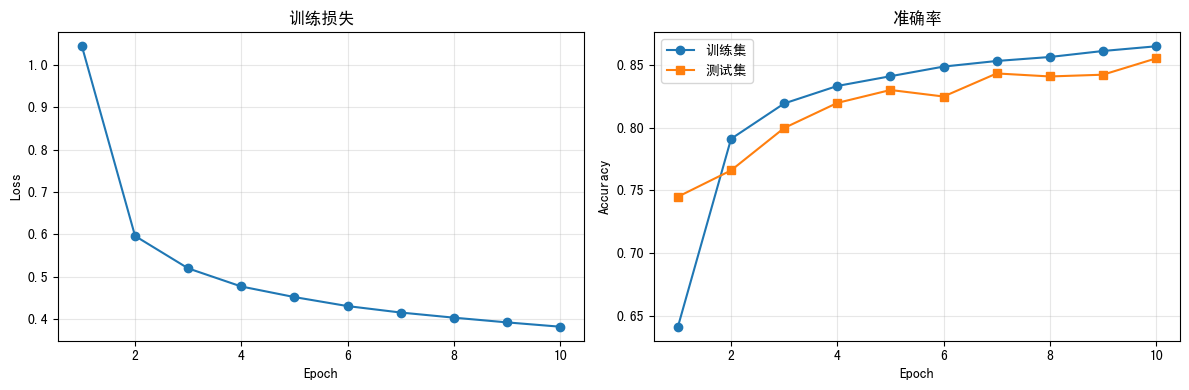


最终结果:
训练准确率: 86.50%
测试准确率: 85.53%


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 损失曲线
ax1.plot(range(1, num_epochs + 1), train_losses, marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('训练损失')
ax1.grid(True, alpha=0.3)

# 准确率曲线
ax2.plot(range(1, num_epochs + 1), train_accs, marker='o', label='训练集')
ax2.plot(range(1, num_epochs + 1), test_accs, marker='s', label='测试集')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('准确率')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n最终结果:')
print(f'训练准确率: {train_accs[-1]:.2%}')
print(f'测试准确率: {test_accs[-1]:.2%}')

---

## 第四部分: PyTorch简洁实现

### 4.1 定义模型

In [16]:
net_concise = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

# 初始化权重
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net_concise.apply(init_weights)

print('模型结构:')
print(net_concise)
print(f'\n参数总数: {sum(p.numel() for p in net_concise.parameters()):,}')

模型结构:
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=10, bias=True)
)

参数总数: 203,530


### 4.2 定义损失函数和优化器

In [17]:
loss_concise = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net_concise.parameters(), lr=0.1)

print('损失函数:', loss_concise)
print('优化器:', trainer)

损失函数: CrossEntropyLoss()
优化器: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


### 4.3 训练模型

In [18]:
def train_epoch_concise(net, train_iter, loss, updater):
    """训练一个迭代周期(简洁版)"""
    metric = [0.0, 0.0, 0.0]
    net.train()  # 设置为训练模式

    for X, y in train_iter:
        y_hat = net(X)
        l = loss(y_hat, y)
        updater.zero_grad()
        l.mean().backward()
        updater.step()

        metric[0] += float(l.sum())
        metric[1] += float(accuracy(y_hat, y))
        metric[2] += y.numel()

    return metric[0] / metric[2], metric[1] / metric[2]

# 开始训练
num_epochs = 10
train_losses_c, train_accs_c, test_accs_c = [], [], []

for epoch in range(num_epochs):
    train_metrics = train_epoch_concise(net_concise, train_iter, loss_concise, trainer)
    test_acc = evaluate_accuracy(net_concise, test_iter)

    train_losses_c.append(train_metrics[0])
    train_accs_c.append(train_metrics[1])
    test_accs_c.append(test_acc)

    print(f'epoch {epoch + 1}, '
          f'loss {train_metrics[0]:.3f}, '
          f'train acc {train_metrics[1]:.3f}, '
          f'test acc {test_acc:.3f}')

epoch 1, loss 1.042, train acc 0.647, test acc 0.721
epoch 2, loss 0.599, train acc 0.787, test acc 0.797
epoch 3, loss 0.515, train acc 0.819, test acc 0.813
epoch 4, loss 0.476, train acc 0.833, test acc 0.819
epoch 5, loss 0.453, train acc 0.840, test acc 0.836
epoch 6, loss 0.431, train acc 0.848, test acc 0.826
epoch 7, loss 0.416, train acc 0.854, test acc 0.841
epoch 8, loss 0.402, train acc 0.858, test acc 0.837
epoch 9, loss 0.392, train acc 0.861, test acc 0.838
epoch 10, loss 0.382, train acc 0.864, test acc 0.839


### 4.4 对比两种实现

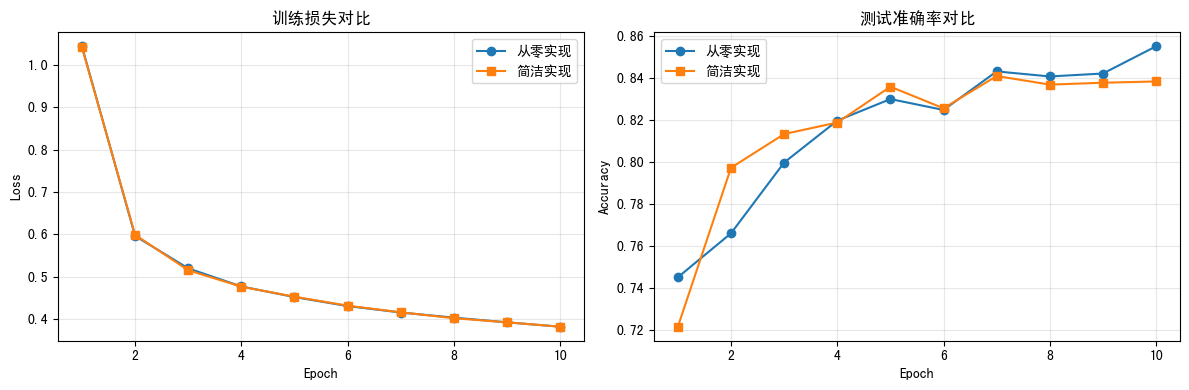

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 损失对比
ax1.plot(range(1, num_epochs + 1), train_losses, marker='o', label='从零实现')
ax1.plot(range(1, num_epochs + 1), train_losses_c, marker='s', label='简洁实现')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('训练损失对比')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 测试准确率对比
ax2.plot(range(1, num_epochs + 1), test_accs, marker='o', label='从零实现')
ax2.plot(range(1, num_epochs + 1), test_accs_c, marker='s', label='简洁实现')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('测试准确率对比')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 第五部分: 反向传播算法

### 5.1 计算图

**前向传播**: 按顺序计算网络输出

```
输入 x → 隐藏层 h = ReLU(W₁x + b₁) → 输出 o = W₂h + b₂ → 损失 L
```

**反向传播**: 利用链式法则计算梯度

```
∂L/∂W₂ ← ∂L/∂o ← ∂L/∂h ← ∂L/∂W₁
```

### 5.2 链式法则

如果 $y = f(u)$ 且 $u = g(x)$,则:
$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$$

**多层网络**:
$$\frac{\partial L}{\partial \mathbf{W}^{(1)}} = \frac{\partial L}{\partial \mathbf{o}} \cdot \frac{\partial \mathbf{o}}{\partial \mathbf{h}} \cdot \frac{\partial \mathbf{h}}{\partial \mathbf{W}^{(1)}}$$

### 5.3 反向传播的优势

1. **高效**: 一次反向传播计算所有梯度
2. **自动化**: 框架自动计算,无需手动推导
3. **可扩展**: 适用于任意深度的网络

### 5.4 手动计算示例

In [20]:
# 简单的两层网络示例
x = torch.randn(1, 2, requires_grad=True)
w1 = torch.randn(2, 3, requires_grad=True)
w2 = torch.randn(3, 1, requires_grad=True)

# 前向传播
h = torch.relu(x @ w1)
y = h @ w2
loss = y.sum()

print('前向传播:')
print(f'  输入 x: {x.shape}')
print(f'  隐藏层 h: {h.shape}')
print(f'  输出 y: {y.shape}')
print(f'  损失: {loss.item():.4f}')

# 反向传播
loss.backward()

print('\n反向传播(梯度):')
print(f'  ∂L/∂x: {x.grad}')
print(f'  ∂L/∂w1: {w1.grad}')
print(f'  ∂L/∂w2: {w2.grad}')

前向传播:
  输入 x: torch.Size([1, 2])
  隐藏层 h: torch.Size([1, 3])
  输出 y: torch.Size([1, 1])
  损失: 0.1097

反向传播(梯度):
  ∂L/∂x: tensor([[-0.0801,  0.1899]])
  ∂L/∂w1: tensor([[0.0946, 0.0000, 0.0000],
        [0.2095, 0.0000, 0.0000]])
  ∂L/∂w2: tensor([[0.3734],
        [0.0000],
        [0.0000]])


### 5.5 梯度消失与梯度爆炸

**梯度消失**: 梯度在反向传播中变得越来越小
- **原因**: Sigmoid/Tanh的导数 < 1,多层相乘导致梯度指数衰减
- **后果**: 深层网络训练困难,前面的层几乎不更新
- **解决**: 使用ReLU,残差连接(ResNet),BatchNorm

**梯度爆炸**: 梯度在反向传播中变得越来越大
- **原因**: 权重初始化不当,网络过深
- **后果**: 参数更新过大,训练不稳定
- **解决**: 梯度裁剪,合适的权重初始化,BatchNorm

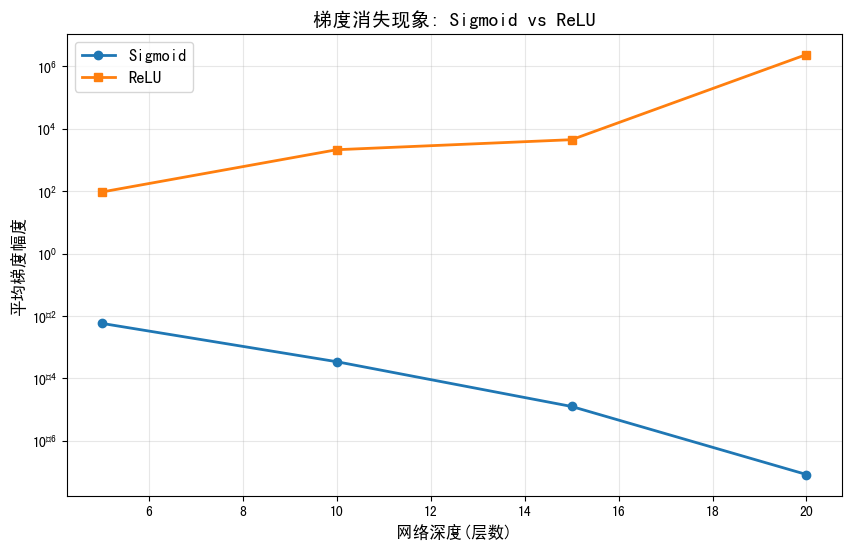

观察:
- Sigmoid: 随着深度增加,梯度急剧衰减(梯度消失!)
- ReLU: 梯度相对稳定,适合深层网络


In [21]:
# 演示梯度消失
def simulate_gradient_vanishing(num_layers=10, activation='sigmoid'):
    """模拟梯度消失"""
    x = torch.randn(1, 10, requires_grad=True)

    # 构建多层网络
    h = x
    for i in range(num_layers):
        w = torch.randn(10, 10, requires_grad=True)
        h = h @ w
        if activation == 'sigmoid':
            h = torch.sigmoid(h)
        elif activation == 'relu':
            h = torch.relu(h)

    loss = h.sum()
    loss.backward()

    return x.grad.abs().mean().item()

# 对比不同激活函数
layers = [5, 10, 15, 20]
grad_sigmoid = [simulate_gradient_vanishing(l, 'sigmoid') for l in layers]
grad_relu = [simulate_gradient_vanishing(l, 'relu') for l in layers]

plt.figure(figsize=(10, 6))
plt.plot(layers, grad_sigmoid, marker='o', label='Sigmoid', linewidth=2)
plt.plot(layers, grad_relu, marker='s', label='ReLU', linewidth=2)
plt.xlabel('网络深度(层数)', fontsize=12)
plt.ylabel('平均梯度幅度', fontsize=12)
plt.title('梯度消失现象: Sigmoid vs ReLU', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

print('观察:')
print('- Sigmoid: 随着深度增加,梯度急剧衰减(梯度消失!)')
print('- ReLU: 梯度相对稳定,适合深层网络')

---

## 小结

### 核心概念

1. **多层感知机(MLP)**:
   - 通过隐藏层学习特征表示
   - 突破线性模型的局限
   - 可以逼近任意复杂函数(通用逼近定理)

2. **激活函数**:
   - 引入非线性,使多层网络有意义
   - ReLU: 简单高效,缓解梯度消失
   - Sigmoid/Tanh: 存在梯度消失问题

3. **反向传播**:
   - 利用链式法则高效计算梯度
   - 深度学习框架自动完成
   - 注意梯度消失/爆炸问题

### 性能对比

| 模型 | 测试准确率 | 参数量 |
|------|-----------|--------|
| Softmax回归 | ~83% | 7,850 |
| MLP(1个隐藏层) | ~88% | 203,530 |

**提升5%!** 隐藏层带来了明显的性能提升。

### 关键要点

- ✅ **隐藏层**是深度学习的基础
- ✅ **激活函数**必不可少
- ✅ **ReLU**是现代神经网络的首选
- ✅ **反向传播**实现高效训练
- ✅ **梯度消失**是深层网络的挑战

## 练习

1. **改变隐藏层大小**: 尝试128, 512, 1024个隐藏单元,观察性能变化
2. **多个隐藏层**: 添加第二个隐藏层,构建更深的网络
3. **不同激活函数**: 使用Sigmoid或Tanh替换ReLU,比较效果
4. **学习率调整**: 测试不同学习率(0.01, 0.05, 0.2, 0.5)
5. **XOR问题**: 用MLP解决XOR分类问题
6. **参数初始化**: 尝试不同的初始化方法(Xavier, He初始化)
7. **梯度裁剪**: 实现梯度裁剪,防止梯度爆炸
8. **批量大小影响**: 测试不同batch_size对训练的影响